# 15 — Emotion, embodiment & social world (exploratory)

**Exploratory analysis.** The thematic families examined here were motivated
partly by patterns observed in the Stage 10 topic landscape and subsequent
human review. They are therefore post-hoc and do not constitute independent
hypothesis tests. Topic membership is defined from semantic evidence before
inspecting within-family rating effects, and all results are interpreted
primarily through effect sizes, confidence intervals, robustness and semantic
coherence.

The 38 Stage-10 survivors (`|δ| ≥ .11`, CI excludes zero) are **seeds for
questions**, not the analysis candidate set. Candidates are retrieved from the
full ~348 mapped topics (leaf ∪ lexical prototypes), coded rating-blind, then
frozen before effects.

**This notebook does not alter H1–H6 or NB13 confirmatory verdicts.**

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import exploratory_ees as ees
from src.stage11_refined_construct_analysis.analysis import exploratory_security as ex
from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

NOTEBOOK = "15_emotion_embodiment_social_world_exploration"
ctx = nh.setup(NOTEBOOK)
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)

ees_cfg = ees.load_exploratory_ees_config(root / "configs/stage11/exploratory_emotion_embodiment_social_world.yaml")
FROZEN = ees.is_frozen(ees_cfg)
PROVISIONAL = ees.is_provisional(ees_cfg)
print(f"Freeze status : frozen={FROZEN} provisional={PROVISIONAL}")
print(f"Freeze note   : {(ees_cfg.get('freeze_note') or '')[:160]}")

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration


Freeze status : frozen=True provisional=False
Freeze note   : Frozen after single-pass LLM coding + human overrides: 56 E3→E8, 133 E4→E5, 47 E5→E2.


## Setup — book frame, shares, tertiles

In [2]:
frame = nh.load_refined_frame(cfg, "strict")
if "book_id" in frame.columns:
    frame = frame.set_index("book_id")
usable = frame[frame["analysable"].fillna(True)].copy() if "analysable" in frame.columns else frame.copy()
work = usable.reset_index()
if "book_id" not in work.columns and usable.index.name == "book_id":
    work["book_id"] = usable.index

shares = ex.topic_share_matrix(cfg)
tertile_counts = ees.load_tertile_topic_counts(cfg)
master = pd.read_parquet(cfg.output_path("constructs_dir") / "master_annotations.parquet")

ees_dir = Path(ees_cfg.get("outputs", {}).get("ees_dir") or cfg.output_path("ees_exploration_dir"))
if not ees_dir.is_absolute():
    ees_dir = root / ees_dir

candidates = pd.read_csv(ees_dir / "candidate_topics.csv")
codes_path = ees_dir / "semantic_codes.csv"
if codes_path.exists():
    semantic_codes = pd.read_csv(codes_path)
else:
    semantic_codes = pd.DataFrame()
    print("WARNING: semantic_codes.csv missing — run pipeline/10_run_ees_coding.py")

construct_dict = ees.construct_dictionary_frame(ees_cfg)
ctx.save_table(candidates, "candidate_topics")
ctx.save_table(semantic_codes, "semantic_codes")
ctx.save_table(construct_dict, "construct_dictionary")
print(f"Candidates: {len(candidates):,} rows | codes: {len(semantic_codes):,} | dict rows: {len(construct_dict):,}")

if not FROZEN:
    print(
        "\n*** PROVISIONAL FREEZE ***\n"
        "Effects below use YAML seed membership. Re-run after LLM+human freeze "
        "(set frozen: true) before presentation claims.\n"
    )

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/candidate_topics.csv  (220 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/semantic_codes.csv  (320 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/construct_dictionary.csv  (1,097 rows)
Candidates: 220 rows | codes: 320 | dict rows: 1,097


In [3]:
work_ees = ees.add_ees_share_columns(work, shares, ees_cfg, level="moderate")
constructs = ees.active_constructs(ees_cfg, level="moderate")
coherence = ees.coherence_table(shares, constructs)
display(coherence)
ctx.save_table(coherence, "construct_robustness")

def _test(df, feat, hyp, label=""):
    gate = coherence.set_index("construct")["status"].to_dict().get(
        feat.replace("EES_", "").replace("EXP_", ""), "measurable"
    )
    # Map EXP_/EES_ family columns back to construct names for gate
    cname = feat
    for prefix in ("EES_", "EXP_"):
        if cname.startswith(prefix):
            cname = cname[len(prefix):]
            break
    # strip trailing _strict/_moderate/_broad
    for suf in ("_strict", "_moderate", "_broad"):
        if cname.endswith(suf):
            cname = cname[: -len(suf)]
            break
    status = coherence.set_index("construct")["status"].to_dict().get(cname, "measurable")
    return nh.test_axis(
        df,
        feat,
        hyp,
        label=label or feat,
        measurement_gate="unmeasurable" if status == "unmeasurable" else "viable",
        effect_gate=GATE,
        expected_sign=None,
        n_replicates=400,
        seed=42,
    )

,construct,n_topics,topic_ids,status,largest_topic_id,largest_topic_mass_share,single_topic_dominated,total_mass
0,emotion_distress_expressed,8,"43,48,66,96,129,143,218,245",measurable,66,0.2482,False,443.8341
1,emotion_physiological_arousal,12,"1,14,23,47,55,64,88,92,107,132,162,166",measurable,1,0.1965,False,732.1473
2,emotion_physical_vulnerability,13,"4,38,44,62,109,122,145,157,159,163,177,179,244",measurable,4,0.4412,False,844.0822
3,emotion_visible_affect,21,"5,11,26,28,29,42,59,72,74,90,97,102,104,128,13...",measurable,5,0.1340,False,"1,290.3789"
4,emotion_containment,3,"119,133,281",measurable,119,0.4527,False,101.9619
5,emotion_coping,7,"21,34,58,60,99,185,240",measurable,21,0.2552,False,284.7926
6,emotion_reappraisal,1,95,thin,95,1.0000,True,42.4852
7,emotion_coregulation,10,"6,36,46,56,57,75,100,103,170,175",measurable,6,0.3505,False,792.4216
8,emotion_physical_comfort,11,"12,31,70,83,98,101,120,124,126,161,358",measurable,126,0.1419,False,388.6251
9,emotion_relief,2,"45,154",thin,45,0.7100,True,156.4367


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/construct_robustness.csv  (23 rows)


---
# Part I — Emotion & embodiment

Narrative emotion **functions** (E0–E11), not mere positive/negative valence.
Motivating literature (interpretive only): Martínez (2024) on physiological
narrated perception; emotion-regulation theory as a conceptual guide — codes
require prose support.

,construct,n_topics,status,mean_share,median_share,mean_high,mean_low,verdict,ols_beta,cliffs_delta,ci_low,ci_high
0,emotion_distress_expressed,8,measurable,0.0277,0.0270,None,None,no reliable effect,-0.5154,-0.0072,-0.0380,0.0217
1,emotion_physiological_arousal,12,measurable,0.0458,0.0412,None,None,directional_only,0.6707,0.0668,0.0425,0.0965
2,emotion_physical_vulnerability,13,measurable,0.0528,0.0484,None,None,no reliable effect,0.0185,-0.0113,-0.0434,0.0178
3,emotion_visible_affect,21,measurable,0.0807,0.0794,None,None,directional_only,0.4802,0.0705,0.0399,0.0984
4,emotion_containment,3,measurable,0.0064,0.0055,None,None,clears_gate,4.2053,0.1822,0.1534,0.2115
5,emotion_coregulation,10,measurable,0.0495,0.0469,None,None,directional_only,0.4074,0.0680,0.0359,0.0979
6,emotion_physical_comfort,11,measurable,0.0243,0.0228,None,None,no reliable effect,0.2396,0.0144,-0.0108,0.0424
7,emotion_relief,2,thin,0.0098,0.0094,None,None,directional_only,0.3478,0.0367,0.0070,0.0674
8,emotion_rumination,1,thin,0.0032,0.0029,None,None,no reliable effect,-5.3891,0.0086,-0.0173,0.0329


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/emotion_effects.csv  (9 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/figures/emotion_function_forest.png


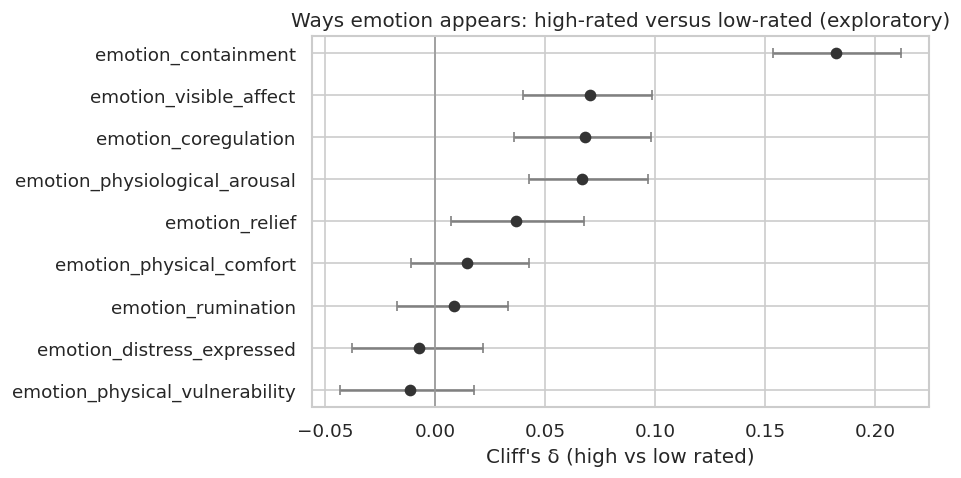

In [4]:
emotion_families = [
    "emotion_distress_expressed",
    "emotion_physiological_arousal",
    "emotion_physical_vulnerability",
    "emotion_visible_affect",
    "emotion_containment",
    "emotion_coregulation",
    "emotion_physical_comfort",
    "emotion_relief",
    "emotion_rumination",
]

emotion_rows = []
for fam in emotion_families:
    col = f"EES_{fam}"
    if col not in work_ees.columns:
        continue
    status = coherence.set_index("construct").loc[fam, "status"] if fam in coherence["construct"].values else "measurable"
    n_topics = int(coherence.set_index("construct").loc[fam, "n_topics"]) if fam in coherence["construct"].values else 0
    res = _test(work_ees, col, "EES", label=fam)
    share = work_ees[col]
    emotion_rows.append(
        {
            "construct": fam,
            "n_topics": n_topics,
            "status": status,
            "mean_share": float(share.mean()),
            "median_share": float(share.median()),
            "mean_high": res.get("mean_high"),
            "mean_low": res.get("mean_low"),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
            "ols_beta": res.get("ols_beta") or res.get("quality_beta"),
        }
    )

# Prefer author-cluster CI when available
try:
    ac = nh.cliffs_delta_author_cluster_ci_many(
        work_ees,
        [f"EES_{f}" for f in emotion_families if f"EES_{f}" in work_ees.columns],
        n_replicates=400,
        seed=42,
    )
    emotion_eff = pd.DataFrame(emotion_rows)
    if len(ac):
        ac = ac.copy()
        ac["construct"] = ac["feature"].str.replace("^EES_", "", regex=True)
        emotion_eff = emotion_eff.drop(columns=["cliffs_delta", "ci_low", "ci_high"], errors="ignore").merge(
            ac[["construct", "cliffs_delta", "ci_low", "ci_high"]],
            on="construct",
            how="left",
        )
except Exception as exc:
    print("Author-cluster CI fallback:", exc)
    emotion_eff = pd.DataFrame(emotion_rows)

display(emotion_eff.round(4))
ctx.save_table(emotion_eff, "emotion_effects")

fig, ax = ees.forest_plot(
    emotion_eff.rename(columns={"construct": "construct"}),
    title="Ways emotion appears: high-rated versus low-rated (exploratory)",
)
ctx.save_figure(fig, "emotion_function_forest")
plt.show()

### Presence versus intensity (corpus-wide 75th percentile gate)

In [5]:
presence_rows = []
for fam in emotion_families:
    col = f"EES_{fam}"
    if col not in work_ees.columns:
        continue
    tab = ees.presence_intensity_by_group(work_ees, col)
    presence_rows.append(tab)
presence_emotion = pd.concat(presence_rows, ignore_index=True) if presence_rows else pd.DataFrame()
display(presence_emotion.round(4))
ctx.save_table(presence_emotion, "emotion_presence_intensity")

,threshold,prevalence,conditional_intensity_mean,conditional_intensity_median,unconditional_mean,unconditional_median,n_present,n_total,group,feature
0,0.0334,0.2500,0.0401,0.0383,0.0277,0.0270,4000,15999,all,EES_emotion_distress_expressed
1,0.0334,0.2263,0.0392,0.0377,0.0275,0.0269,1151,5086,high,EES_emotion_distress_expressed
2,0.0334,0.2782,0.0411,0.0389,0.0280,0.0270,1499,5389,low,EES_emotion_distress_expressed
3,0.0558,0.2500,0.0755,0.0697,0.0458,0.0412,4000,15999,all,EES_emotion_physiological_arousal
4,0.0558,0.2719,0.0746,0.0698,0.0467,0.0422,1383,5086,high,EES_emotion_physiological_arousal
5,0.0558,0.2295,0.0757,0.0690,0.0447,0.0401,1237,5389,low,EES_emotion_physiological_arousal
6,0.0649,0.2500,0.0820,0.0777,0.0528,0.0484,4000,15999,all,EES_emotion_physical_vulnerability
7,0.0649,0.2283,0.0808,0.0760,0.0521,0.0480,1161,5086,high,EES_emotion_physical_vulnerability
8,0.0649,0.2731,0.0837,0.0799,0.0535,0.0488,1472,5389,low,EES_emotion_physical_vulnerability
9,0.0924,0.2500,0.1062,0.1021,0.0807,0.0794,4000,15999,all,EES_emotion_visible_affect


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/emotion_presence_intensity.csv  (27 rows)


### Emotion over narrative position (begin | middle | end)

The question shifts from "how much emotion" to "where each emotional function appears."
Read rising vs falling lines across begin → middle → end. If a function intensifies toward
the ending in higher-rated books specifically, it suggests that better-rated romance
concentrates that emotional function more narrowly at the climax / resolution.

,construct,contrast,cliffs_delta,ci_low,ci_high,verdict
0,emotion_distress_expressed,end_minus_begin,0.0258,0.0033,0.0480,directional_only
1,emotion_physiological_arousal,end_minus_begin,-0.0002,-0.0214,0.0231,no reliable effect
2,emotion_coregulation,end_minus_begin,-0.0423,-0.0658,-0.0195,directional_only
3,emotion_relief,end_minus_begin,-0.0108,-0.0320,0.0108,no reliable effect
4,emotion_rumination,end_minus_begin,-0.0504,-0.0739,-0.0272,directional_only
5,family_presence,end_minus_begin,-0.0130,-0.0346,0.0101,no reliable effect
6,social_pressure_conflict,end_minus_begin,-0.0105,-0.0320,0.0145,no reliable effect


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/emotion_position_effects.csv  (7 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/emotion_position_trajectories.csv  (63 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/figures/emotion_trajectories.png


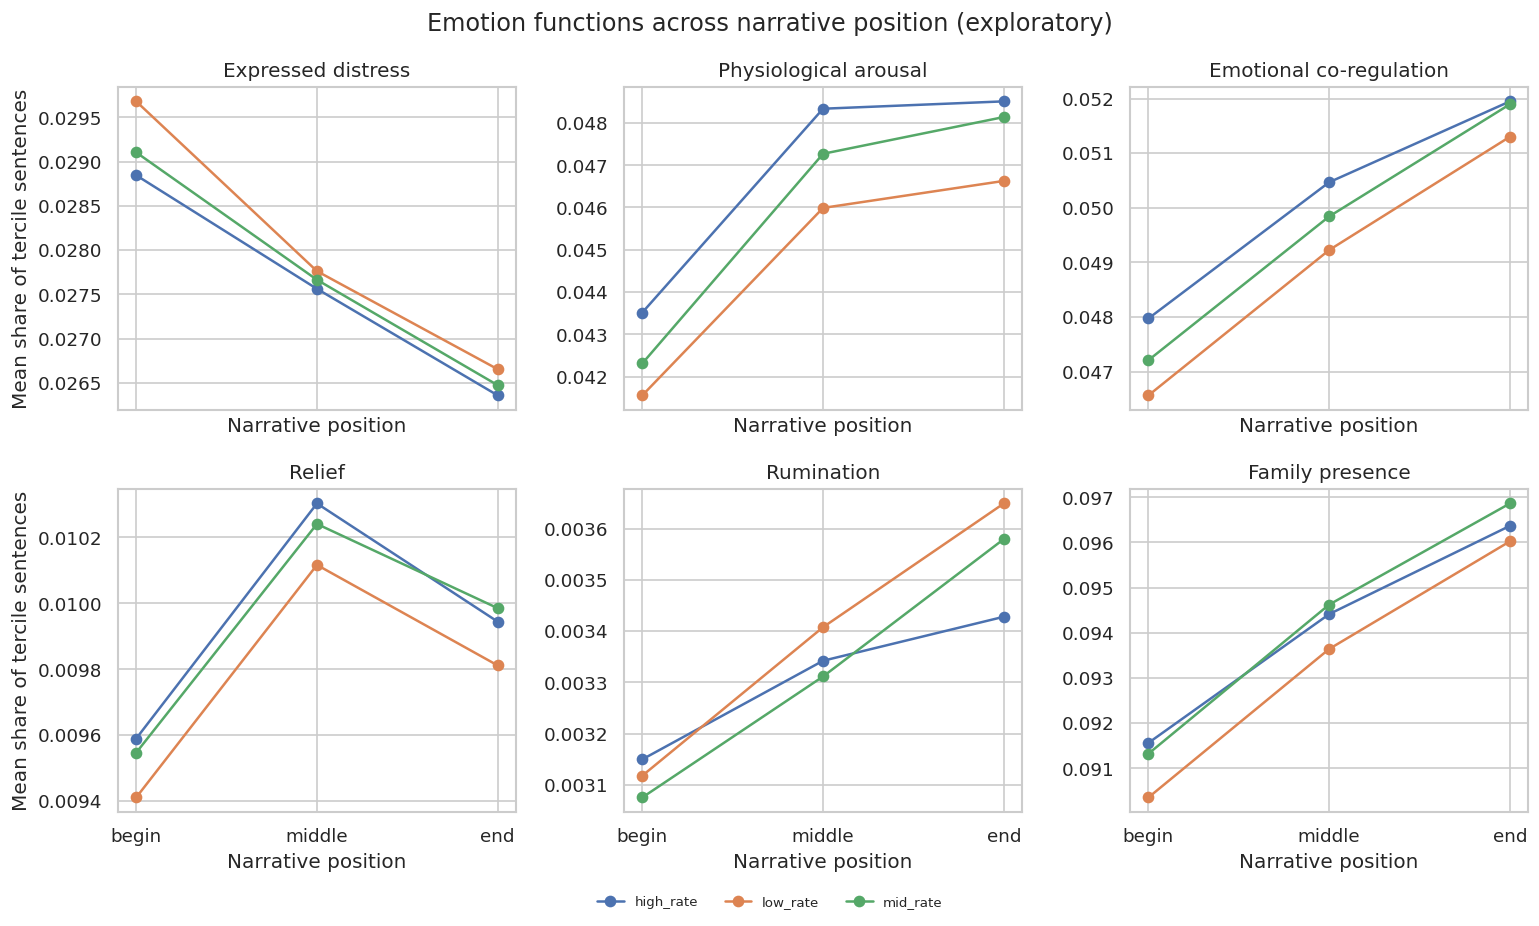

In [6]:
_EMOTION_HUMAN = {
    "emotion_distress_expressed": "Expressed distress",
    "emotion_containment": "Emotional containment",
    "emotion_coregulation": "Emotional co-regulation",
    "emotion_relief_joy": "Relief / joy",
    "emotion_overwhelm": "Emotional overwhelm",
    "emotion_anger_frustration": "Anger / frustration",
}
pos_names = list(ees_cfg.get("position_constructs") or [])
pos_constructs = {
    name: constructs.get(name, [])
    for name in pos_names
    if name in constructs
}
traj, pos_effects, delta_frame = ees.position_effects_table(
    tertile_counts,
    pos_constructs,
    work_ees,
    test_fn=_test,
)
display(pos_effects.round(4))
ctx.save_table(pos_effects, "emotion_position_effects")
ctx.save_table(traj, "emotion_position_trajectories")

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True)
axes = axes.ravel()
_legend_handles = []
for i, feat in enumerate(list(pos_constructs)[:6]):
    human = _EMOTION_HUMAN.get(feat, feat.replace("emotion_", "").replace("_", " ").capitalize())
    ees.trajectory_plot(traj, feature=feat, ax=axes[i], title=human)
    axes[i].get_legend().remove()
    if i == 0:
        for h in axes[i].get_lines():
            _legend_handles.append(h)
    axes[i].set_ylabel("Mean share of tercile sentences" if i % 3 == 0 else "")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Emotion functions across narrative position (exploratory)")
fig.legend(_legend_handles, [h.get_label() for h in _legend_handles],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03), fontsize=8, frameon=False)
fig.tight_layout(pad=1.1, w_pad=1.4, h_pad=1.4)
ctx.save_figure(fig, "emotion_trajectories")
plt.show()

---
# Part II — Felt body versus looked-at body

Body as medium of lived experience vs body as object of observation.
Keep B3 (tattoos/scars) separate — Topic 370 is an important exception to
“more bodily description = lower ratings.”

,construct,n_topics,status,mean_share,cliffs_delta,ci_low,ci_high,verdict
0,body_interoceptive,29.0000,measurable,0.0926,0.0672,0.0477,0.0896,directional_only
1,body_vulnerable,19.0000,measurable,0.0870,0.0378,0.0167,0.0576,directional_only
2,body_markings,1.0000,thin,0.0024,0.0981,0.0758,0.1184,directional_only
3,body_external_appearance,18.0000,measurable,0.0717,-0.0281,-0.0508,-0.0074,directional_only
4,body_grooming,4.0000,measurable,0.0119,-0.1304,-0.1511,-0.1090,clears_gate
5,felt_body,48.0000,measurable,0.1795,0.0641,0.0420,0.0895,directional_only
6,looked_at_body,22.0000,measurable,0.0836,-0.0629,-0.0849,-0.0412,directional_only
7,felt_vs_looked_logratio,NaN,,0.7770,0.1121,0.0907,0.1320,clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/embodiment_effects.csv  (8 rows)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/felt_vs_looked_body.csv  (8 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/figures/felt_vs_looked_body.png


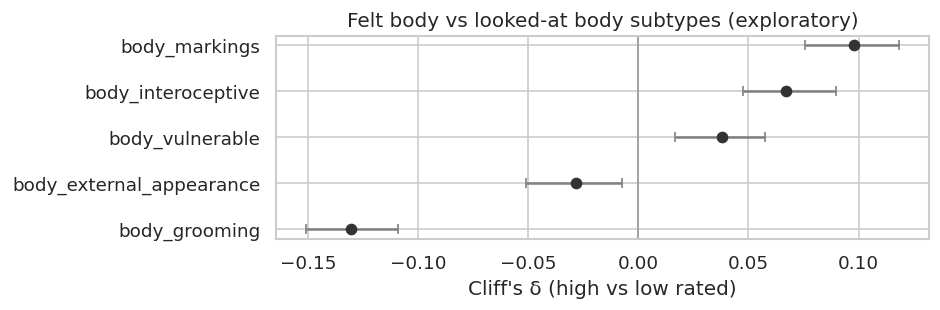

In [7]:
body_families = [
    "body_interoceptive",
    "body_vulnerable",
    "body_markings",
    "body_external_appearance",
    "body_grooming",
]
body_rows = []
for fam in body_families:
    col = f"EES_{fam}"
    if col not in work_ees.columns:
        continue
    res = _test(work_ees, col, "EES", label=fam)
    status = coherence.set_index("construct").loc[fam, "status"] if fam in coherence["construct"].values else ""
    n_topics = int(coherence.set_index("construct").loc[fam, "n_topics"]) if fam in coherence["construct"].values else 0
    body_rows.append(
        {
            "construct": fam,
            "n_topics": n_topics,
            "status": status,
            "mean_share": float(work_ees[col].mean()),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )

# Composites + log-ratio
for name in ("felt_body", "looked_at_body", "felt_vs_looked_logratio"):
    col = f"EES_{name}"
    if col not in work_ees.columns:
        continue
    res = _test(work_ees, col, "EES", label=name)
    body_rows.append(
        {
            "construct": name,
            "n_topics": len(constructs.get(name, [])) if name != "felt_vs_looked_logratio" else None,
            "status": coherence.set_index("construct")["status"].to_dict().get(name, ""),
            "mean_share": float(work_ees[col].mean()),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )

embodiment_eff = pd.DataFrame(body_rows)
display(embodiment_eff.round(4))
ctx.save_table(embodiment_eff, "embodiment_effects")

felt_looked = embodiment_eff[
    embodiment_eff["construct"].isin(
        body_families + ["felt_body", "looked_at_body", "felt_vs_looked_logratio"]
    )
].copy()
ctx.save_table(felt_looked, "felt_vs_looked_body")

fig, ax = ees.forest_plot(
    felt_looked[felt_looked["construct"].isin(body_families)],
    title="Felt body vs looked-at body subtypes (exploratory)",
)
ctx.save_figure(fig, "felt_vs_looked_body")
plt.show()

---
# Part III — Family & social embeddedness

Nested measures: family presence (S1–S8), supportive embeddedness, social
pressure/conflict. Positive δ for family pressure does **not** imply harmony —
social stakes may matter more than social warmth.

,construct,n_topics,status,mean_share,cliffs_delta,ci_low,ci_high,verdict
0,family_presence,51,measurable,0.0939,0.0464,0.0255,0.0675,directional_only
1,supportive_social_embeddedness,17,measurable,0.0340,0.0780,0.0564,0.0994,directional_only
2,social_pressure_conflict,32,measurable,0.0524,0.0090,-0.0121,0.0309,no reliable effect


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/family_social_effects.csv  (3 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/figures/family_social_forest.png


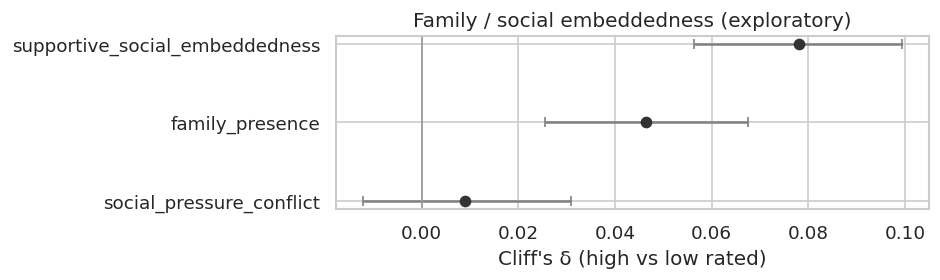

,construct,mean,median,cliffs_delta,ci_low,ci_high,verdict,note
0,social_domain_richness,1.2501,1.0000,0.0227,0.0043,0.0440,directional_only,Count of social domains above corpus p75; not ...


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/social_domain_richness.csv  (1 rows)


In [8]:
social_families = [
    "family_presence",
    "supportive_social_embeddedness",
    "social_pressure_conflict",
]
social_rows = []
for fam in social_families:
    col = f"EES_{fam}"
    if col not in work_ees.columns:
        continue
    res = _test(work_ees, col, "EES", label=fam)
    social_rows.append(
        {
            "construct": fam,
            "n_topics": int(coherence.set_index("construct").loc[fam, "n_topics"])
            if fam in coherence["construct"].values
            else 0,
            "status": coherence.set_index("construct").loc[fam, "status"]
            if fam in coherence["construct"].values
            else "",
            "mean_share": float(work_ees[col].mean()),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )
family_social_eff = pd.DataFrame(social_rows)
display(family_social_eff.round(4))
ctx.save_table(family_social_eff, "family_social_effects")

fig, ax = ees.forest_plot(
    family_social_eff,
    title="Family / social embeddedness (exploratory)",
)
ctx.save_figure(fig, "family_social_forest")
plt.show()

# Social-domain richness (≠ NB14 Shannon thematic richness)
domains = ees_cfg.get("social_domains") or {}
work_ees["EES_social_domain_richness"] = ees.social_domain_richness(
    work_ees, shares, domains
).values
sdr = _test(work_ees, "EES_social_domain_richness", "EES", label="social_domain_richness")
sdr_row = pd.DataFrame(
    [
        {
            "construct": "social_domain_richness",
            "mean": float(work_ees["EES_social_domain_richness"].mean()),
            "median": float(work_ees["EES_social_domain_richness"].median()),
            "cliffs_delta": sdr.get("cliffs_delta"),
            "ci_low": sdr.get("ci_low"),
            "ci_high": sdr.get("ci_high"),
            "verdict": sdr.get("verdict"),
            "note": "Count of social domains above corpus p75; not Shannon entropy",
        }
    ]
)
display(sdr_row.round(4))
ctx.save_table(sdr_row, "social_domain_richness")

---
# Part IV — Three pre-registered cross-family tests

In [9]:
# 12. Embodied distress × interpersonal co-regulation
ix1 = ees.interaction_ols(
    work_ees,
    "EES_embodied_distress",
    "EES_co_regulation",
    name="embodied_distress_x_coregulation",
)
# 13. Family embeddedness × emotional reassurance (coregulation proxy)
ix2 = ees.interaction_ols(
    work_ees,
    "EES_family_presence",
    "EES_emotion_coregulation",
    name="family_x_emotional_reassurance",
)
cross_rows = []
for ix in (ix1, ix2):
    if ix.get("status") != "ok":
        cross_rows.append({"name": ix.get("name"), "status": ix.get("status")})
        continue
    inter = ix.get("interaction") or {}
    cross_rows.append(
        {
            "name": ix.get("name"),
            "status": "ok",
            "beta_interaction": inter.get("beta"),
            "se": inter.get("se"),
            "p": inter.get("p"),
            "ci_low": inter.get("ci_low"),
            "ci_high": inter.get("ci_high"),
            "beta_x": (ix.get("z_x") or {}).get("beta"),
            "beta_y": (ix.get("z_y") or {}).get("beta"),
        }
    )
cross_df = pd.DataFrame(cross_rows)
display(cross_df.round(4))
ctx.save_table(cross_df, "cross_family_interactions")

# 14. Felt × looked-at 2×2 (descriptive)
quad = ees.median_split_quadrants(
    work_ees,
    "EES_felt_body",
    "EES_looked_at_body",
    x_high="high_felt",
    x_low="low_felt",
    y_high="high_looked",
    y_low="low_looked",
)
display(quad.round(4))
ctx.save_table(quad, "felt_looked_quadrants")

,name,status,beta_interaction,se,p,ci_low,ci_high,beta_x,beta_y
0,embodied_distress_x_coregulation,ok,0.0044,0.0019,0.0181,0.0008,0.0081,0.0123,0.0117
1,family_x_emotional_reassurance,ok,-0.0021,0.0009,0.0242,-0.0039,-0.0003,0.0061,0.0075


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/cross_family_interactions.csv  (2 rows)


,x_bin,y_bin,n,mean_rating,median_rating,x_median_cut,y_median_cut
0,high_felt,high_looked,4589,3.9207,3.9102,0.1795,0.0828
1,high_felt,low_looked,3411,3.9454,3.9279,0.1795,0.0828
2,low_felt,high_looked,3411,3.9077,3.9100,0.1795,0.0828
3,low_felt,low_looked,4588,3.9166,3.9119,0.1795,0.0828


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/felt_looked_quadrants.csv  (4 rows)


---
# Part V — Cognition screen (hard gate: ≥3 coherent topics)

In [10]:
cog_codes = (ees_cfg.get("code_membership") or {}).get("cognition") or {}
cog_rows = []
n_coherent = 0
for code, tids in cog_codes.items():
    tids = list(tids or [])
    if code in ("generic_off_target",):
        continue
    if not tids:
        cog_rows.append({"code": code, "n_topics": 0, "status": "empty", "cliffs_delta": float("nan")})
        continue
    col = f"EES_tmp_cog_{code}"
    tmp = work_ees.copy()
    tmp[col] = ex._align_series_to_frame(ex.topic_set_share(shares, tids), tmp).values
    res = _test(tmp, col, "EES", label=code)
    coherent = code not in ("generic_off_target",) and len(tids) >= 1
    if coherent and code != "generic_off_target":
        n_coherent += len(tids)
    cog_rows.append(
        {
            "code": code,
            "n_topics": len(tids),
            "topic_ids": ",".join(str(t) for t in tids),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )
cognition_screen = pd.DataFrame(cog_rows)
cognition_screen["family_test_allowed"] = n_coherent >= 3
display(cognition_screen.round(4))
print(f"Coherent cognition topic count (excl. off-target): {n_coherent}")
if n_coherent < 3:
    print("HARD RULE: do not construct/test a cognition family (fewer than 3 coherent topics).")
ctx.save_table(cognition_screen, "cognition_screen")

,code,n_topics,topic_ids,cliffs_delta,ci_low,ci_high,verdict,family_test_allowed
0,indecision,3,"21,34,263",0.0229,-0.0001,0.0439,no reliable effect,True
1,realization_reappraisal,8,"21,34,44,95,177,263,311,313",0.0168,-0.0075,0.0394,no reliable effect,True
2,relationship_interpretation,4,"4,75,287,301",-0.0078,-0.0302,0.0134,no reliable effect,True
3,religious_spiritual,1,287,0.1302,0.1066,0.1493,clears_gate,True
4,rumination,1,55,0.1437,0.1221,0.1654,clears_gate,True
5,self_reflection,23,"4,44,50,60,62,64,80,99,109,136,142,159,169,177...",-0.0444,-0.0662,-0.0218,directional_only,True


Coherent cognition topic count (excl. off-target): 40
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/cognition_screen.csv  (6 rows)


---
# Part VI — Work / institutional life screen

,code,n_topics,topic_ids,cliffs_delta,ci_low,ci_high,verdict
0,economic_pressure,8,"18,22,34,112,191,249,277,345",-0.0887,-0.1093,-0.0664,directional_only
7,transactional_business,8,"18,110,112,140,191,277,345,360",-0.0712,-0.0916,-0.0508,directional_only
1,generic_logistics,7,"18,121,147,269,277,363,367",-0.0515,-0.0703,-0.0315,directional_only
4,occupational_competence,8,"79,110,112,137,140,178,189,277",-0.0380,-0.0604,-0.0171,directional_only
5,shared_work,7,"79,137,140,158,189,277,340",-0.0206,-0.0435,0.0012,no reliable effect
6,status_wealth,2,"191,277",-0.0184,-0.0384,0.0023,no reliable effect
3,institutional_setting,12,"10,34,121,137,140,141,249,269,277,320,340,363",-0.0102,-0.0313,0.0121,no reliable effect
2,hierarchy_power,8,"10,121,140,141,249,275,277,363",0.0731,0.0526,0.0962,directional_only


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/work_screen.csv  (8 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/figures/work_screen_forest.png


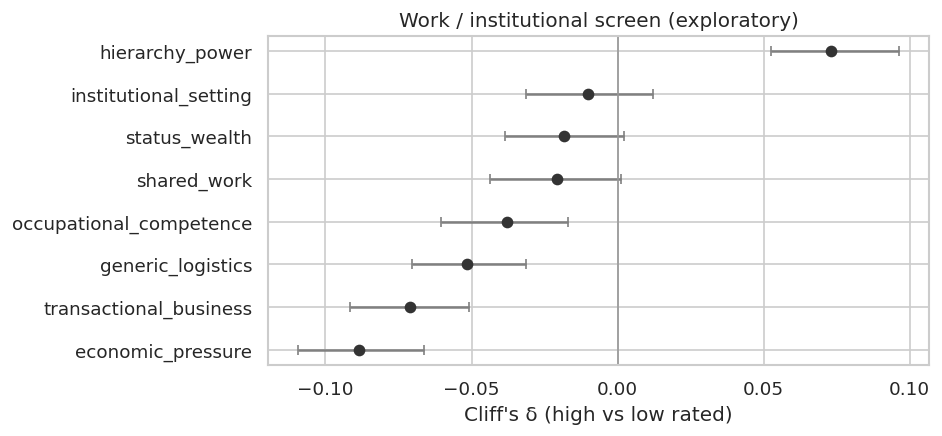

In [11]:
work_codes = (ees_cfg.get("code_membership") or {}).get("work") or {}
work_rows = []
coherent_work = 0
for code, tids in work_codes.items():
    tids = list(tids or [])
    if not tids:
        work_rows.append({"code": code, "n_topics": 0, "cliffs_delta": float("nan"), "verdict": "empty"})
        continue
    col = f"EES_tmp_work_{code}"
    tmp = work_ees.copy()
    tmp[col] = ex._align_series_to_frame(ex.topic_set_share(shares, tids), tmp).values
    res = _test(tmp, col, "EES", label=code)
    if code != "generic_logistics":
        coherent_work += len(tids)
    work_rows.append(
        {
            "code": code,
            "n_topics": len(tids),
            "topic_ids": ",".join(str(t) for t in tids),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )
work_screen = pd.DataFrame(work_rows)
display(work_screen.sort_values("cliffs_delta").round(4))
ctx.save_table(work_screen, "work_screen")
if coherent_work >= 3:
    fig, ax = ees.forest_plot(
        work_screen.dropna(subset=["cliffs_delta"]).rename(columns={"code": "construct"}),
        title="Work / institutional screen (exploratory)",
    )
    ctx.save_figure(fig, "work_screen_forest")
    plt.show()
else:
    print("Fewer than 3 coherent work topics — category-level controlled tests skipped.")

---
# Part VII — Safeguards: author-half stability + integrated summary

In [12]:
stability_feats = [
    f"EES_{c}"
    for c in (
        emotion_families
        + body_families
        + social_families
        + ["felt_body", "looked_at_body", "felt_vs_looked_logratio", "social_domain_richness"]
    )
    if f"EES_{c}" in work_ees.columns
]
stability = ees.author_split_stability(
    work_ees,
    stability_feats,
    test_fn=_test,
    seed=int(ees_cfg.get("author_split_seed", 42)),
)
stability["construct"] = stability["construct"].str.replace("^EES_", "", regex=True)
display(stability.round(4))
ctx.save_table(stability, "author_split_stability")

# Strict → moderate → broad for key families
traj_key = {
    k: v
    for k, v in (ees_cfg.get("families") or {}).items()
    if k in (
        "emotion_distress_expressed",
        "emotion_physiological_arousal",
        "emotion_coregulation",
        "body_external_appearance",
        "body_interoceptive",
        "family_presence",
    )
}
breadth = ex.trajectory_effects(work_ees, traj_key, test_fn=_test, hyp="EES")
display(breadth.round(4))
ctx.save_table(breadth, "strict_moderate_broad_robustness")

,construct,delta_full,ci_low_full,ci_high_full,n_full,delta_half_A,ci_low_half_A,ci_high_half_A,n_half_A,delta_half_B,ci_low_half_B,ci_high_half_B,n_half_B
0,emotion_distress_expressed,-0.0072,-0.0277,0.0147,15999,0.0190,-0.0107,0.0496,8048,-0.0343,-0.0650,-0.0026,7951
1,emotion_physiological_arousal,0.0668,0.0470,0.0888,15999,0.0660,0.0362,0.0988,8048,0.0680,0.0352,0.1007,7951
2,emotion_physical_vulnerability,-0.0113,-0.0331,0.0104,15999,-0.0014,-0.0311,0.0314,8048,-0.0220,-0.0561,0.0113,7951
3,emotion_visible_affect,0.0705,0.0488,0.0927,15999,0.0654,0.0333,0.0942,8048,0.0757,0.0466,0.1091,7951
4,emotion_containment,0.1822,0.1624,0.2037,15999,0.1844,0.1571,0.2154,8048,0.1800,0.1487,0.2116,7951
5,emotion_coregulation,0.0680,0.0481,0.0894,15999,0.0617,0.0310,0.0922,8048,0.0747,0.0465,0.1063,7951
6,emotion_physical_comfort,0.0144,-0.0062,0.0354,15999,0.0171,-0.0117,0.0519,8048,0.0119,-0.0202,0.0432,7951
7,emotion_relief,0.0367,0.0170,0.0592,15999,0.0324,-0.0004,0.0627,8048,0.0410,0.0121,0.0740,7951
8,emotion_rumination,0.0086,-0.0135,0.0302,15999,0.0064,-0.0252,0.0396,8048,0.0108,-0.0202,0.0417,7951
9,body_interoceptive,0.0672,0.0477,0.0896,15999,0.0693,0.0404,0.1007,8048,0.0654,0.0299,0.0978,7951


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/author_split_stability.csv  (21 rows)


,family,level,feature,n_topics,cliffs_delta,ci_low,ci_high,verdict,note
0,emotion_distress_expressed,strict,EXP_emotion_distress_expressed_strict,8,-0.0072,-0.0277,0.0147,no reliable effect,
1,emotion_distress_expressed,moderate,EXP_emotion_distress_expressed_moderate,8,-0.0072,-0.0277,0.0147,no reliable effect,
2,emotion_distress_expressed,broad,EXP_emotion_distress_expressed_broad,8,-0.0072,-0.0277,0.0147,no reliable effect,
3,emotion_physiological_arousal,strict,EXP_emotion_physiological_arousal_strict,12,0.0668,0.0470,0.0888,directional_only,
4,emotion_physiological_arousal,moderate,EXP_emotion_physiological_arousal_moderate,12,0.0668,0.0470,0.0888,directional_only,
5,emotion_physiological_arousal,broad,EXP_emotion_physiological_arousal_broad,12,0.0668,0.0470,0.0888,directional_only,
6,emotion_coregulation,strict,EXP_emotion_coregulation_strict,10,0.0680,0.0481,0.0894,directional_only,
7,emotion_coregulation,moderate,EXP_emotion_coregulation_moderate,10,0.0680,0.0481,0.0894,directional_only,
8,emotion_coregulation,broad,EXP_emotion_coregulation_broad,10,0.0680,0.0481,0.0894,directional_only,
9,body_external_appearance,strict,EXP_body_external_appearance_strict,18,-0.0281,-0.0508,-0.0074,directional_only,


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/strict_moderate_broad_robustness.csv  (18 rows)


### Integrated presentation figure

Candidate claim (only if broader frozen constructs confirm it):
higher-rated romances move **inward** into felt emotional/physical experience and
**outward** into family/social stakes, while giving less attention to generic
visual attractiveness.

## Integrated summary

The bar chart below brings together the headline results from all three domains explored in
this notebook. The interpretive pattern: **higher-rated romance emphasises felt, expressive,
relationally regulated experience more than externally appraised appearance**. The negative
grooming / appearance result connects with the robust finding in Stage 10 — external
description of characters is less prevalent in well-rated books.

,construct,cliffs_delta,ci_low,ci_high
0,Emotion distress expressed,-0.0072,-0.0380,0.0217
1,Emotion physiological arousal,0.0668,0.0425,0.0965
3,Emotion visible affect,0.0705,0.0399,0.0984
5,Co-regulation,0.0680,0.0359,0.0979
6,Emotion physical comfort,0.0144,-0.0108,0.0424
9,Interoceptive / felt body,0.0672,0.0477,0.0896
10,Pain / physical vulnerability,0.0378,0.0167,0.0576
11,"Body markings (tattoos, scars)",0.0981,0.0758,0.1184
12,External body appearance,-0.0281,-0.0508,-0.0074
13,Body grooming / appearance,-0.1304,-0.1511,-0.1090


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables/integrated_summary_effects.csv  (15 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/figures/integrated_summary.png


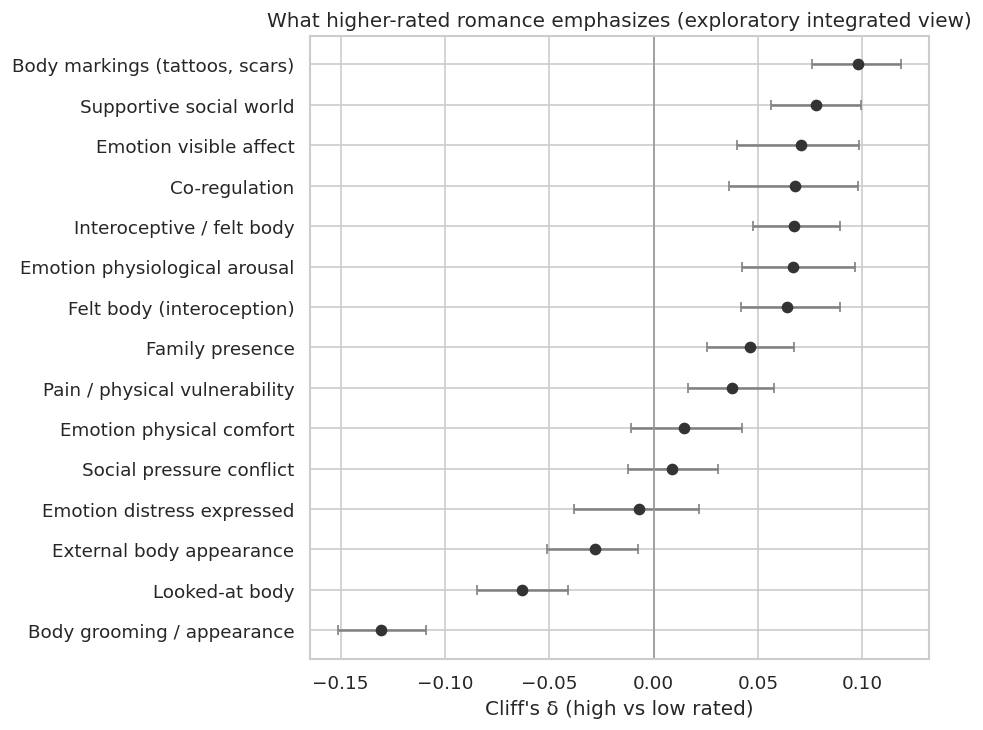

In [13]:
_INTEGRATED_HUMAN = {
    "emotion_containment": "Emotional containment",
    "emotion_coregulation": "Co-regulation",
    "felt_body": "Felt body (interoception)",
    "supportive_social_embeddedness": "Supportive social world",
    "body_grooming": "Body grooming / appearance",
    "body_markings": "Body markings (tattoos, scars)",
    "body_external_appearance": "External body appearance",
    "looked_at_body": "Looked-at body",
    "body_interoceptive": "Interoceptive / felt body",
    "body_vulnerable": "Pain / physical vulnerability",
}
summary_constructs = [
    "emotion_distress_expressed",
    "emotion_physiological_arousal",
    "emotion_coregulation",
    "emotion_physical_comfort",
    "emotion_visible_affect",
    "body_interoceptive",
    "body_vulnerable",
    "body_markings",
    "body_external_appearance",
    "body_grooming",
    "family_presence",
    "supportive_social_embeddedness",
    "social_pressure_conflict",
    "felt_body",
    "looked_at_body",
]
parts = []
for src in (emotion_eff, embodiment_eff, family_social_eff):
    if len(src):
        parts.append(src[["construct", "cliffs_delta", "ci_low", "ci_high"]].copy())
integrated = pd.concat(parts, ignore_index=True)
integrated = integrated[integrated["construct"].isin(summary_constructs)].drop_duplicates("construct")
integrated["construct"] = integrated["construct"].map(
    lambda c: _INTEGRATED_HUMAN.get(c, c.replace("_", " ").capitalize())
)
display(integrated.round(4))
ctx.save_table(integrated, "integrated_summary_effects")

fig, ax = ees.forest_plot(
    integrated,
    title="What higher-rated romance emphasizes (exploratory integrated view)",
)
ctx.save_figure(fig, "integrated_summary")
plt.show()

## Outputs checklist

Tables and figures under
`results/.../notebook_analysis/15_emotion_embodiment_social_world_exploration/`.

Next steps: run `pipeline/10_run_ees_coding.py` (live LLM), human-freeze
`code_membership` / `families`, set `frozen: true`, then re-execute this notebook.

In [14]:
print("Done.")
print(f"Tables → {ctx.tables_dir.relative_to(root)}")
print(f"Figures → {ctx.figures_dir.relative_to(root)}")
print(f"Provisional freeze: {PROVISIONAL} | frozen={FROZEN}")

Done.
Tables → results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/tables
Figures → results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/15_emotion_embodiment_social_world_exploration/figures
Provisional freeze: False | frozen=True
